# Serving And Fallback Analysis

This notebook examines how the research result is reflected in the serving layer. The served model uses SVD for known users because SVD produced the best rating prediction results, and it uses popularity fallback for unknown users because popularity was strong in offline top-k evaluation and is honest for cold start.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

DATA_PATH = PROJECT_ROOT / "data" / "cleaned" / "cleaned_ratings_with_time.csv"
MODEL_PATH = PROJECT_ROOT / "models" / "svd_model.pkl"

plt.style.use("default")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

if not DATA_PATH.exists():
    raise FileNotFoundError("Run `make data` from the project root before this notebook.")
if not MODEL_PATH.exists():
    raise FileNotFoundError("Run `make train` from the project root before this notebook.")


## 1. Load Data And Service

The service layer is the same logic used by the FastAPI app. This keeps the notebook, API, and tests aligned.


In [2]:
from src.recommender_service import RecommenderService

ratings = pd.read_csv(DATA_PATH, parse_dates=["timestamp_datetime"])
service = RecommenderService.from_artifacts(MODEL_PATH, DATA_PATH, model_name="svd", model_version="notebook")
service.health()


{'status': 'healthy', 'model_name': 'svd', 'model_version': 'notebook', 'users': 943, 'movies': 1682, 'ratings': 100000}

## 2. Inspect A Known User

User `196` is a known MovieLens user. For known users, the service can use SVD because it has rating history for that user.


In [3]:
user_id = 196
user_history = ratings[ratings["user_id"] == user_id].copy().sort_values("timestamp_datetime")

pd.DataFrame({
    "user_id": [user_id],
    "ratings": [len(user_history)],
    "mean_rating": [user_history["rating"].mean()],
    "first_rating": [user_history["timestamp_datetime"].min()],
    "last_rating": [user_history["timestamp_datetime"].max()],
})


,user_id,ratings,mean_rating,first_rating,last_rating
0,196,39,3.615385,1997-12-04 15:55:49,1997-12-04 16:18:25


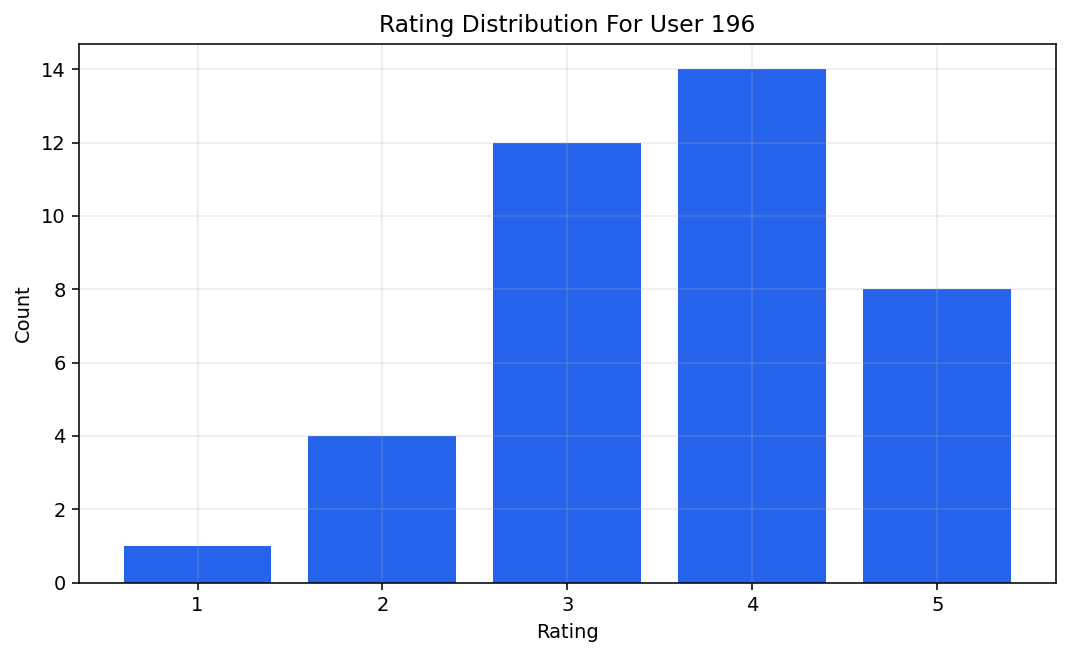

In [4]:
counts = user_history["rating"].value_counts().sort_index()

fig, ax = plt.subplots()
ax.bar(counts.index.astype(str), counts.values, color="#2563EB")
ax.set_title(f"Rating Distribution For User {user_id}")
ax.set_xlabel("Rating")
ax.set_ylabel("Count")
plt.show()


## 3. User History As Concrete Context

The serving analysis includes user history so the recommendation context is explicit. These are some of the movies user `196` rated most highly.


In [5]:
top_history = (
    user_history.sort_values(["rating", "timestamp_datetime"], ascending=[False, False])
    .head(10)[["title", "rating", "timestamp_datetime"]]
)
top_history


,title,rating,timestamp_datetime
16834,"American President, The (1995)",5,1997-12-04 16:13:37
2374,Ace Ventura: Pet Detective (1994),5,1997-12-04 16:13:37
7842,Being There (1979),5,1997-12-04 16:11:51
52726,"Fish Called Wanda, A (1988)",5,1997-12-04 16:10:20
1896,Stand by Me (1986),5,1997-12-04 16:09:53
36281,Secrets & Lies (1996),5,1997-12-04 16:09:13
17102,Babe (1995),5,1997-12-04 16:09:13
13733,"English Patient, The (1996)",5,1997-12-04 15:55:49
18853,Up in Smoke (1978),4,1997-12-04 16:15:28
23189,Kids in the Hall: Brain Candy (1996),4,1997-12-04 16:15:10


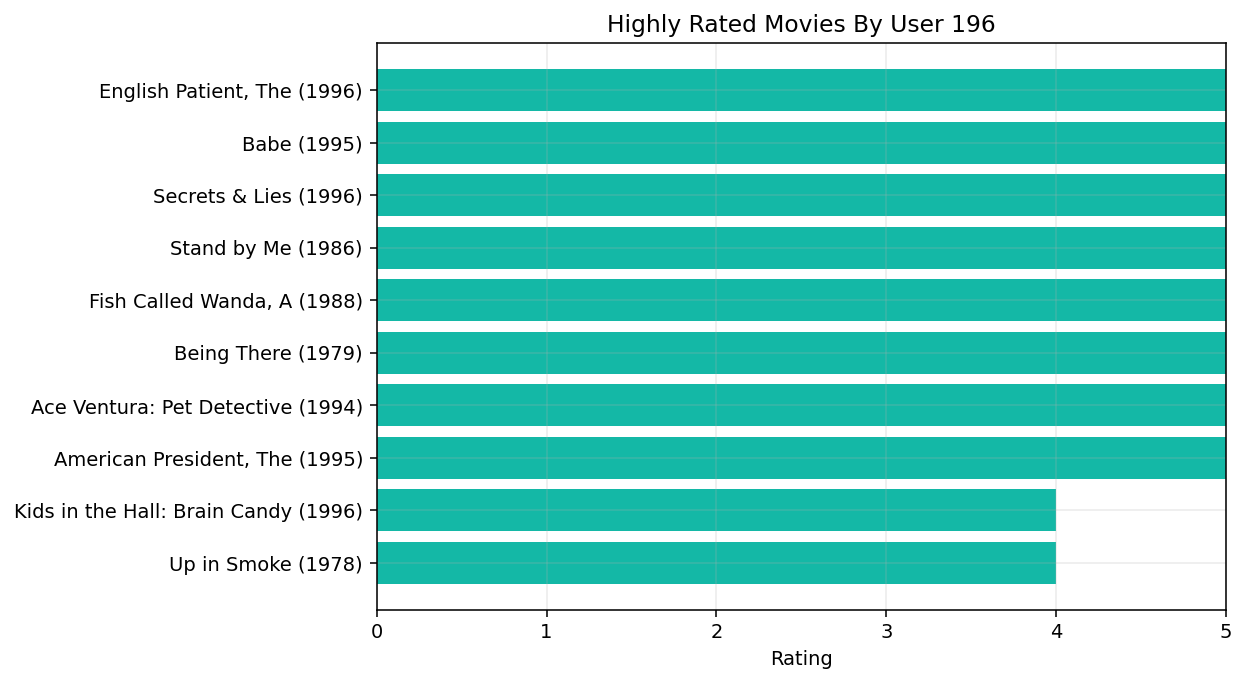

In [6]:
plot_history = top_history.sort_values("rating")

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(plot_history["title"], plot_history["rating"], color="#14B8A6")
ax.set_title(f"Highly Rated Movies By User {user_id}")
ax.set_xlabel("Rating")
ax.set_xlim(0, 5)
plt.tight_layout()
plt.show()


## 4. Personalized SVD Recommendations

The service scores movies the user has not already rated, sorts them, and returns the top recommendations. The `reason` column makes the behavior transparent.


In [7]:
known_response = service.recommend(user_id=user_id, k=10, exclude_seen=True)
known_recs = pd.DataFrame(known_response["recommendations"])
known_response_summary = {
    key: known_response[key]
    for key in ["user_id", "model_name", "model_version", "fallback_used", "exclude_seen", "latency_ms"]
}
known_response_summary, known_recs


({'user_id': 196, 'model_name': 'svd', 'model_version': 'notebook', 'fallback_used': False, 'exclude_seen': True, 'latency_ms': 7.59},    rank  movie_id  ...  score                  reason
0     1       318  ...  4.674  personalized_svd_score
1     2      1449  ...  4.550  personalized_svd_score
2     3       357  ...  4.535  personalized_svd_score
3     4        12  ...  4.519  personalized_svd_score
4     5        98  ...  4.517  personalized_svd_score
5     6       178  ...  4.494  personalized_svd_score
6     7       427  ...  4.480  personalized_svd_score
7     8       496  ...  4.473  personalized_svd_score
8     9       480  ...  4.462  personalized_svd_score
9    10        64  ...  4.446  personalized_svd_score

[10 rows x 5 columns])

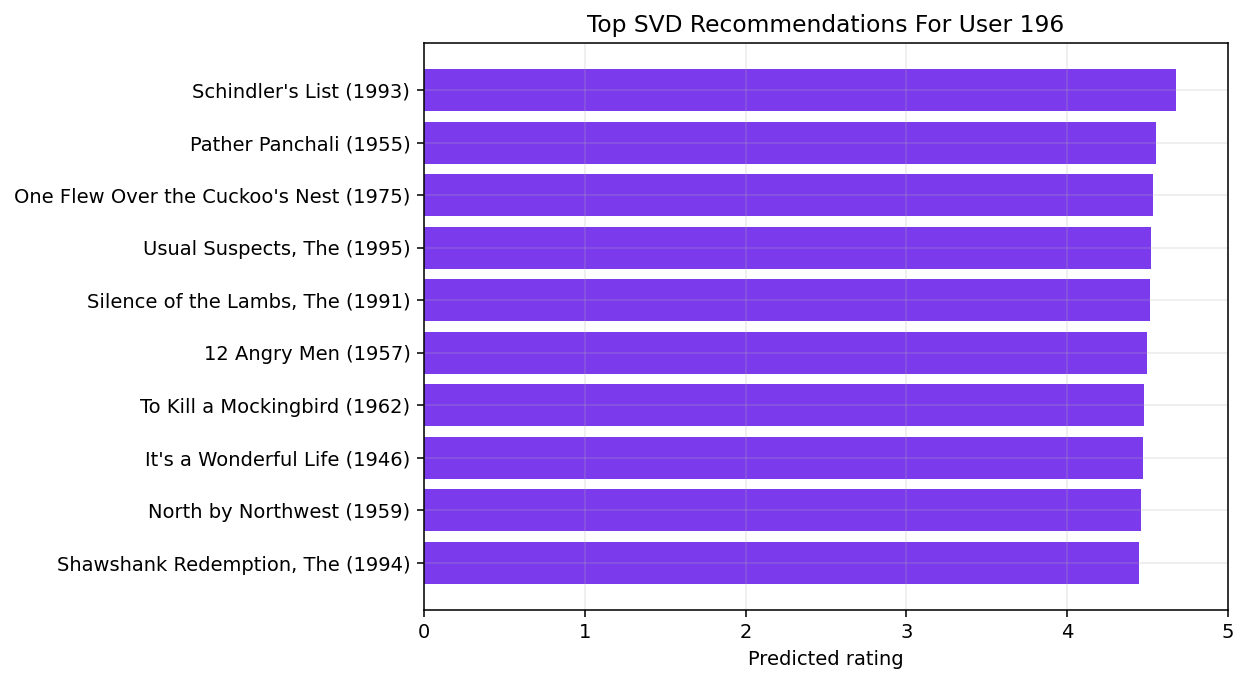

In [8]:
plot_recs = known_recs.sort_values("score")

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(plot_recs["title"], plot_recs["score"], color="#7C3AED")
ax.set_title(f"Top SVD Recommendations For User {user_id}")
ax.set_xlabel("Predicted rating")
ax.set_xlim(0, 5)
plt.tight_layout()
plt.show()


## 5. Seen Item Exclusion

A recommender should not suggest movies the user already rated. This check verifies that the top-10 recommendations do not overlap with the user's history.


In [9]:
seen_items = set(user_history["item_id"].astype(int))
recommended_items = set(known_recs["movie_id"].astype(int))

{
    "seen_count": len(seen_items),
    "recommended_count": len(recommended_items),
    "overlap_count": len(seen_items & recommended_items),
}


{'seen_count': 39, 'recommended_count': 10, 'overlap_count': 0}

## 6. Unknown User Fallback

User `9999` does not exist in MovieLens 100k. In that case the service does not pretend to personalize. It switches to popularity fallback and marks `fallback_used=True`.


In [10]:
unknown_response = service.recommend(user_id=9999, k=10, exclude_seen=True)
unknown_recs = pd.DataFrame(unknown_response["recommendations"])
unknown_response_summary = {
    key: unknown_response[key]
    for key in ["user_id", "model_name", "model_version", "fallback_used", "exclude_seen", "latency_ms"]
}
unknown_response_summary, unknown_recs


({'user_id': 9999, 'model_name': 'popularity_fallback', 'model_version': 'notebook', 'fallback_used': True, 'exclude_seen': True, 'latency_ms': 1.65},    rank  movie_id  ...  score                 reason
0     1       318  ...  4.436  cold_start_popularity
1     2       483  ...  4.420  cold_start_popularity
2     3        64  ...  4.414  cold_start_popularity
3     4       408  ...  4.412  cold_start_popularity
4     5       169  ...  4.393  cold_start_popularity
5     6        12  ...  4.355  cold_start_popularity
6     7       603  ...  4.348  cold_start_popularity
7     8        50  ...  4.345  cold_start_popularity
8     9       114  ...  4.329  cold_start_popularity
9    10       178  ...  4.284  cold_start_popularity

[10 rows x 5 columns])

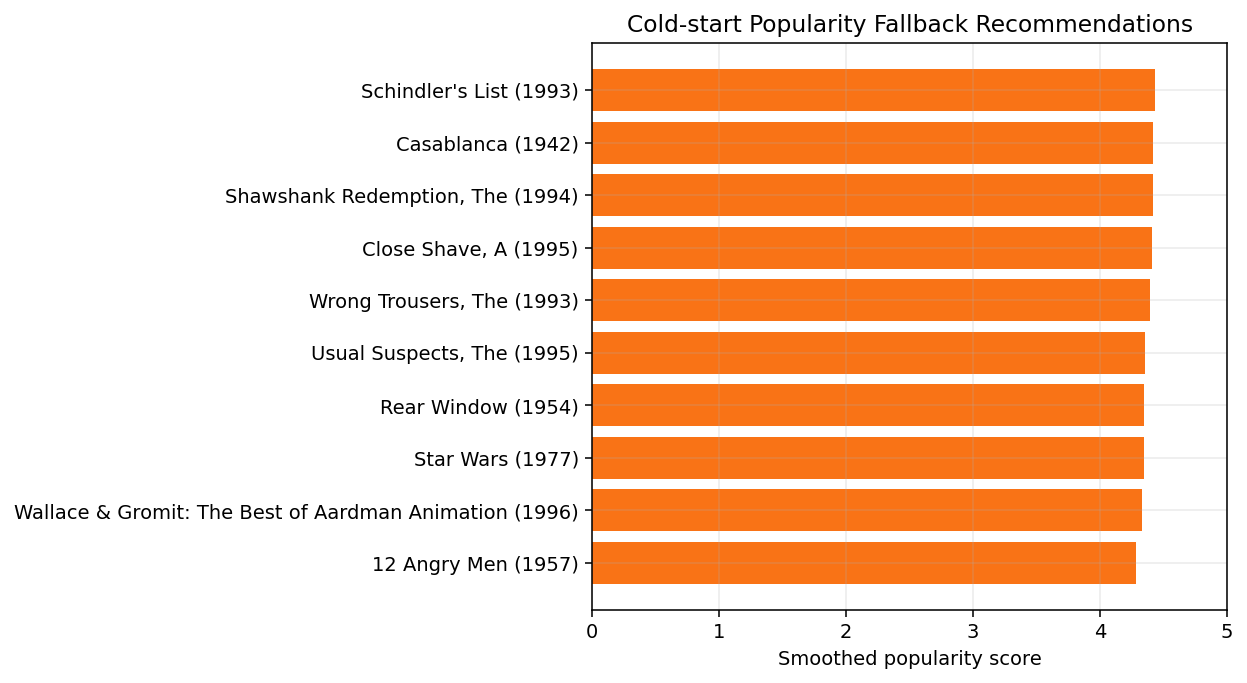

In [11]:
plot_fallback = unknown_recs.sort_values("score")

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(plot_fallback["title"], plot_fallback["score"], color="#F97316")
ax.set_title("Cold-start Popularity Fallback Recommendations")
ax.set_xlabel("Smoothed popularity score")
ax.set_xlim(0, 5)
plt.tight_layout()
plt.show()


## 7. Serving Interpretation

The serving behavior mirrors the research conclusion. Known users get personalized SVD recommendations because SVD is the strongest rating predictor. Unknown users get the popularity fallback because popularity is simple, strong, and honest when no user history exists.
